# Analysis of Hospital Charges vs. Medicare Payments using HCPCS Codes
### Identifying pricing gaps and outliers in U.S. healthcare billing data


In [50]:
# Import data from Sql Server - Just 100k Rows
import pandas as pd
import pyodbc

con = pyodbc.connect(
    'Driver={SQL Server};'
    'Server=LAPTOP-ATVSJVFO\SQLEXPRESS;'
    'Database=healthcare;'
    'Trusted_Connection=yes;'
)


query = '''
SELECT TOP 100000 *
FROM [healthcare].[dbo].[SQL Server Destination]
'''

df = pd.read_sql(query, con)


df.head()

,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_MI,Rndrng_Prvdr_Crdntls,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_St1,Rndrng_Prvdr_St2,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,...,HCPCS_Desc,HCPCS_Drug_Ind,Place_Of_Srvc,Tot_Benes,Tot_Srvcs,Tot_Bene_Day_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Avg_Mdcr_Stdzd_Amt
0,1003000126,Enkeshafi,Ardalan,NA,M.D.,I,6410 Rockledge Dr Ste 304,NA,Bethesda,MD,...,Hospital observation care on day of discharge,N,F,42,44,44,288.93477273,76.932045455,58.619772727,53.307954545
1,1003000126,Enkeshafi,Ardalan,NA,M.D.,I,6410 Rockledge Dr Ste 304,NA,Bethesda,MD,...,"Initial hospital observation care per day, typ...",N,F,17,17,17,424.80411765,144.92,109.15529412,97.278823529
2,1003000126,Enkeshafi,Ardalan,NA,M.D.,I,6410 Rockledge Dr Ste 304,NA,Bethesda,MD,...,"Initial hospital observation care per day, typ...",N,F,35,35,35,686.56428571,189.99885714,151.59685714,140.73314286
3,1003000126,Enkeshafi,Ardalan,NA,M.D.,I,6410 Rockledge Dr Ste 304,NA,Bethesda,MD,...,"Initial hospital inpatient care per day, typic...",N,F,16,16,16,894.99125,100.009375,79.264375,78.499375
4,1003000126,Enkeshafi,Ardalan,NA,M.D.,I,6410 Rockledge Dr Ste 304,NA,Bethesda,MD,...,"Initial hospital inpatient care per day, typic...",N,F,12,12,12,511.915,144.20166667,112.94666667,103.72416667


### Understanding The Dataset

In [51]:
df.shape

(100000, 28)

In [52]:
df.columns

Index(['Rndrng_NPI', 'Rndrng_Prvdr_Last_Org_Name', 'Rndrng_Prvdr_First_Name',
       'Rndrng_Prvdr_MI', 'Rndrng_Prvdr_Crdntls', 'Rndrng_Prvdr_Ent_Cd',
       'Rndrng_Prvdr_St1', 'Rndrng_Prvdr_St2', 'Rndrng_Prvdr_City',
       'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_State_FIPS',
       'Rndrng_Prvdr_Zip5', 'Rndrng_Prvdr_RUCA', 'Rndrng_Prvdr_RUCA_Desc',
       'Rndrng_Prvdr_Cntry', 'Rndrng_Prvdr_Type',
       'Rndrng_Prvdr_Mdcr_Prtcptg_Ind', 'HCPCS_Cd', 'HCPCS_Desc',
       'HCPCS_Drug_Ind', 'Place_Of_Srvc', 'Tot_Benes', 'Tot_Srvcs',
       'Tot_Bene_Day_Srvcs', 'Avg_Sbmtd_Chrg', 'Avg_Mdcr_Alowd_Amt',
       'Avg_Mdcr_Pymt_Amt', 'Avg_Mdcr_Stdzd_Amt'],
      dtype='object')

### Removing Irrelevant Columns and Renaming the Rest for Better Understanding

In [53]:
cols_drop = ['Rndrng_Prvdr_MI','Rndrng_Prvdr_Ent_Cd','Rndrng_Prvdr_St2','Rndrng_Prvdr_Cntry','Rndrng_Prvdr_State_FIPS','Rndrng_Prvdr_RUCA',
                'Rndrng_Prvdr_RUCA_Desc','HCPCS_Drug_Ind','Place_Of_Srvc']

df.drop(columns=cols_drop, inplace=True)

In [54]:
df.head()

,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_Crdntls,Rndrng_Prvdr_St1,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_Type,Rndrng_Prvdr_Mdcr_Prtcptg_Ind,HCPCS_Cd,HCPCS_Desc,Tot_Benes,Tot_Srvcs,Tot_Bene_Day_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Avg_Mdcr_Stdzd_Amt
0,1003000126,Enkeshafi,Ardalan,M.D.,6410 Rockledge Dr Ste 304,Bethesda,MD,20817,Internal Medicine,Y,99217,Hospital observation care on day of discharge,42,44,44,288.93477273,76.932045455,58.619772727,53.307954545
1,1003000126,Enkeshafi,Ardalan,M.D.,6410 Rockledge Dr Ste 304,Bethesda,MD,20817,Internal Medicine,Y,99219,"Initial hospital observation care per day, typ...",17,17,17,424.80411765,144.92,109.15529412,97.278823529
2,1003000126,Enkeshafi,Ardalan,M.D.,6410 Rockledge Dr Ste 304,Bethesda,MD,20817,Internal Medicine,Y,99220,"Initial hospital observation care per day, typ...",35,35,35,686.56428571,189.99885714,151.59685714,140.73314286
3,1003000126,Enkeshafi,Ardalan,M.D.,6410 Rockledge Dr Ste 304,Bethesda,MD,20817,Internal Medicine,Y,99221,"Initial hospital inpatient care per day, typic...",16,16,16,894.99125,100.009375,79.264375,78.499375
4,1003000126,Enkeshafi,Ardalan,M.D.,6410 Rockledge Dr Ste 304,Bethesda,MD,20817,Internal Medicine,Y,99222,"Initial hospital inpatient care per day, typic...",12,12,12,511.915,144.20166667,112.94666667,103.72416667


In [55]:
df.shape

(100000, 19)

In [56]:
df.columns

Index(['Rndrng_NPI', 'Rndrng_Prvdr_Last_Org_Name', 'Rndrng_Prvdr_First_Name',
       'Rndrng_Prvdr_Crdntls', 'Rndrng_Prvdr_St1', 'Rndrng_Prvdr_City',
       'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_Zip5', 'Rndrng_Prvdr_Type',
       'Rndrng_Prvdr_Mdcr_Prtcptg_Ind', 'HCPCS_Cd', 'HCPCS_Desc', 'Tot_Benes',
       'Tot_Srvcs', 'Tot_Bene_Day_Srvcs', 'Avg_Sbmtd_Chrg',
       'Avg_Mdcr_Alowd_Amt', 'Avg_Mdcr_Pymt_Amt', 'Avg_Mdcr_Stdzd_Amt'],
      dtype='object')

In [57]:
df.rename(columns={'Rndrng_NPI': 'Provider_NPI','Rndrng_Prvdr_Last_Org_Name': 'Provider_Last_Name_or_Org','Rndrng_Prvdr_First_Name': 'Provider_First_Name',
    'Rndrng_Prvdr_Crdntls': 'Provider_Credentials','Rndrng_Prvdr_St1': 'Provider_Address','Rndrng_Prvdr_City': 'Provider_City',
    'Rndrng_Prvdr_State_Abrvtn': 'Provider_State','Rndrng_Prvdr_Zip5': 'Provider_Zip','Rndrng_Prvdr_Type': 'Provider_Type',
    'Rndrng_Prvdr_Mdcr_Prtcptg_Ind': 'Medicare_Participation_Indicator','Tot_Benes': 'Total_Beneficiaries', 
    'Tot_Srvcs': 'Total_Services','Tot_Bene_Day_Srvcs': 'Total_Beneficiary_Day_Services','Avg_Sbmtd_Chrg': 'Avg_Submitted_Charge',
    'Avg_Mdcr_Alowd_Amt': 'Avg_Medicare_Allowed','Avg_Mdcr_Pymt_Amt': 'Avg_Medicare_Payment','Avg_Mdcr_Stdzd_Amt': 'Avg_Medicare_Standardized'
}, inplace=True)

df.head()

,Provider_NPI,Provider_Last_Name_or_Org,Provider_First_Name,Provider_Credentials,Provider_Address,Provider_City,Provider_State,Provider_Zip,Provider_Type,Medicare_Participation_Indicator,HCPCS_Cd,HCPCS_Desc,Total_Beneficiaries,Total_Services,Total_Beneficiary_Day_Services,Avg_Submitted_Charge,Avg_Medicare_Allowed,Avg_Medicare_Payment,Avg_Medicare_Standardized
0,1003000126,Enkeshafi,Ardalan,M.D.,6410 Rockledge Dr Ste 304,Bethesda,MD,20817,Internal Medicine,Y,99217,Hospital observation care on day of discharge,42,44,44,288.93477273,76.932045455,58.619772727,53.307954545
1,1003000126,Enkeshafi,Ardalan,M.D.,6410 Rockledge Dr Ste 304,Bethesda,MD,20817,Internal Medicine,Y,99219,"Initial hospital observation care per day, typ...",17,17,17,424.80411765,144.92,109.15529412,97.278823529
2,1003000126,Enkeshafi,Ardalan,M.D.,6410 Rockledge Dr Ste 304,Bethesda,MD,20817,Internal Medicine,Y,99220,"Initial hospital observation care per day, typ...",35,35,35,686.56428571,189.99885714,151.59685714,140.73314286
3,1003000126,Enkeshafi,Ardalan,M.D.,6410 Rockledge Dr Ste 304,Bethesda,MD,20817,Internal Medicine,Y,99221,"Initial hospital inpatient care per day, typic...",16,16,16,894.99125,100.009375,79.264375,78.499375
4,1003000126,Enkeshafi,Ardalan,M.D.,6410 Rockledge Dr Ste 304,Bethesda,MD,20817,Internal Medicine,Y,99222,"Initial hospital inpatient care per day, typic...",12,12,12,511.915,144.20166667,112.94666667,103.72416667


### Checking For Any Null Value

In [58]:
df.isna().sum()

Provider_NPI                        0
Provider_Last_Name_or_Org           0
Provider_First_Name                 0
Provider_Credentials                0
Provider_Address                    0
Provider_City                       0
Provider_State                      0
Provider_Zip                        0
Provider_Type                       0
Medicare_Participation_Indicator    0
HCPCS_Cd                            0
HCPCS_Desc                          0
Total_Beneficiaries                 0
Total_Services                      0
Total_Beneficiary_Day_Services      0
Avg_Submitted_Charge                0
Avg_Medicare_Allowed                0
Avg_Medicare_Payment                0
Avg_Medicare_Standardized           0
dtype: int64

In [59]:
df.dtypes

Provider_NPI                        object
Provider_Last_Name_or_Org           object
Provider_First_Name                 object
Provider_Credentials                object
Provider_Address                    object
Provider_City                       object
Provider_State                      object
Provider_Zip                        object
Provider_Type                       object
Medicare_Participation_Indicator    object
HCPCS_Cd                            object
HCPCS_Desc                          object
Total_Beneficiaries                 object
Total_Services                      object
Total_Beneficiary_Day_Services      object
Avg_Submitted_Charge                object
Avg_Medicare_Allowed                object
Avg_Medicare_Payment                object
Avg_Medicare_Standardized           object
dtype: object

### Changing Data Types to Relevant Ones

In [60]:
num_col = ['Total_Beneficiaries', 'Total_Services', 'Total_Beneficiary_Day_Services','Avg_Submitted_Charge', 'Avg_Medicare_Allowed',
         'Avg_Medicare_Payment', 'Avg_Medicare_Standardized']

df[num_col] = df[num_col].apply(pd.to_numeric, errors='coerce')
df.dtypes

Provider_NPI                         object
Provider_Last_Name_or_Org            object
Provider_First_Name                  object
Provider_Credentials                 object
Provider_Address                     object
Provider_City                        object
Provider_State                       object
Provider_Zip                         object
Provider_Type                        object
Medicare_Participation_Indicator     object
HCPCS_Cd                             object
HCPCS_Desc                           object
Total_Beneficiaries                   int64
Total_Services                      float64
Total_Beneficiary_Day_Services        int64
Avg_Submitted_Charge                float64
Avg_Medicare_Allowed                float64
Avg_Medicare_Payment                float64
Avg_Medicare_Standardized           float64
dtype: object

### Checking The Value Counts And Describing The Data

In [61]:
df['Provider_Type'].value_counts().head(10)

Diagnostic Radiology                      11657
Internal Medicine                          8684
Family Practice                            8471
Nurse Practitioner                         8073
Physician Assistant                        5212
Cardiology                                 3881
Physical Therapist in Private Practice     3654
Ophthalmology                              2595
Orthopedic Surgery                         2589
Emergency Medicine                         2289
Name: Provider_Type, dtype: int64

In [62]:
df['HCPCS_Cd'].value_counts().head(10)

99214    4904
99213    4738
99204    2321
99232    1727
99203    1695
99215    1472
99233    1434
99223    1357
G0008    1321
99212    1141
Name: HCPCS_Cd, dtype: int64

In [63]:
df.describe()

,Total_Beneficiaries,Total_Services,Total_Beneficiary_Day_Services,Avg_Submitted_Charge,Avg_Medicare_Allowed,Avg_Medicare_Payment,Avg_Medicare_Standardized
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,72.563950,241.607659,116.857020,399.555394,105.602179,82.486702,81.628936
std,211.035642,2509.628832,392.682649,1375.285229,328.426085,262.063379,265.513715
min,11.000000,11.000000,11.000000,0.000245,0.000245,0.000231,0.000231
25%,17.000000,20.000000,20.000000,69.854818,27.654486,21.700294,19.792448
50%,31.000000,42.000000,40.000000,167.204651,68.931291,52.861037,53.614364
75%,71.000000,113.000000,101.000000,346.500000,121.875939,90.356534,89.711867
max,16435.000000,304000.000000,34454.000000,97729.116250,30404.916000,24238.426000,25440.880000


### Top 10 Code By Services

In [64]:
df.groupby(['HCPCS_Cd', 'HCPCS_Desc'])['Total_Services'].sum().sort_values(ascending = False).head(10).reset_index()

,HCPCS_Cd,HCPCS_Desc,Total_Services
0,99214,Established patient office or other outpatient...,1007384.0
1,A0425,"Ground mileage, per statute mile",990298.1
2,Q0138,"Injection, ferumoxytol, for treatment of iron ...",950640.0
3,Q9967,"Low osmolar contrast material, 300-399 mg/ml i...",915507.0
4,99213,Established patient office or other outpatient...,728219.0
5,J0717,"Injection, certolizumab pegol, 1 mg (code may ...",713201.0
6,A9575,"Injection, gadoterate meglumine, 0.1 ml",694227.0
7,J0585,"Injection, onabotulinumtoxina, 1 unit",646310.0
8,97110,Therapy procedure using exercise to develop st...,622455.0
9,J0897,"Injection, denosumab, 1 mg",618994.0


In [65]:
top_services = df.groupby(['HCPCS_Cd', 'HCPCS_Desc'])['Total_Services'].sum().sort_values(ascending = False).head(10).reset_index()

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

fig = px.bar(
    top_services, 
    x='HCPCS_Cd', 
    y='Total_Services', 
    hover_data=['HCPCS_Desc'], 
    color='Total_Services',
    title='Top 10 Services',
    color_continuous_scale='viridis'
)

fig.update_layout(xaxis_title='Services', yaxis_title='Total Services', height=600, width=1000, coloraxis_showscale=False, 
                  title_x= 0.5)
fig.show()

### Top HCPCS Code Compared to Hospital Charges, Medicare Allowed, and What Medicare Paid


In [67]:
top_expensive = df.groupby(['HCPCS_Cd', 'HCPCS_Desc'])[
    ['Avg_Submitted_Charge', 'Avg_Medicare_Allowed', 'Avg_Medicare_Payment']
].mean().sort_values(by='Avg_Submitted_Charge', ascending=False).head(10).reset_index()


top_expensive.head(10)

,HCPCS_Cd,HCPCS_Desc,Avg_Submitted_Charge,Avg_Medicare_Allowed,Avg_Medicare_Payment
0,69930,Insertion of cochlear device,73285.933333,30404.916000,24238.426000
1,64582,Insertion of hypoglossal nerve neurostimulator...,71759.818182,23141.199091,18444.493636
2,A0431,"Ambulance service, conventional air services, ...",41578.753959,4968.939174,3962.345659
3,27279,Fusion of pelvic joint using imaging guidance,41451.633000,6908.188989,5512.326230
4,47135,Transplantation of donor liver,37395.088235,3897.095294,3118.720000
5,52353,Crushing of stone of ureter using an endoscope,30150.000000,384.966563,307.171875
6,51999,Other procedure on bladder using an endoscope,30000.000000,1502.716471,1203.324706
7,37227,Removal of plaque and insertion of stents in a...,27022.773333,11880.581074,9493.601966
8,36906,Removal and/or dissolving of blood clot in hem...,26057.333333,7847.282026,6256.666324
9,22869,Placement of stabilizing device to lower spine...,25387.500000,5336.281765,4256.591765


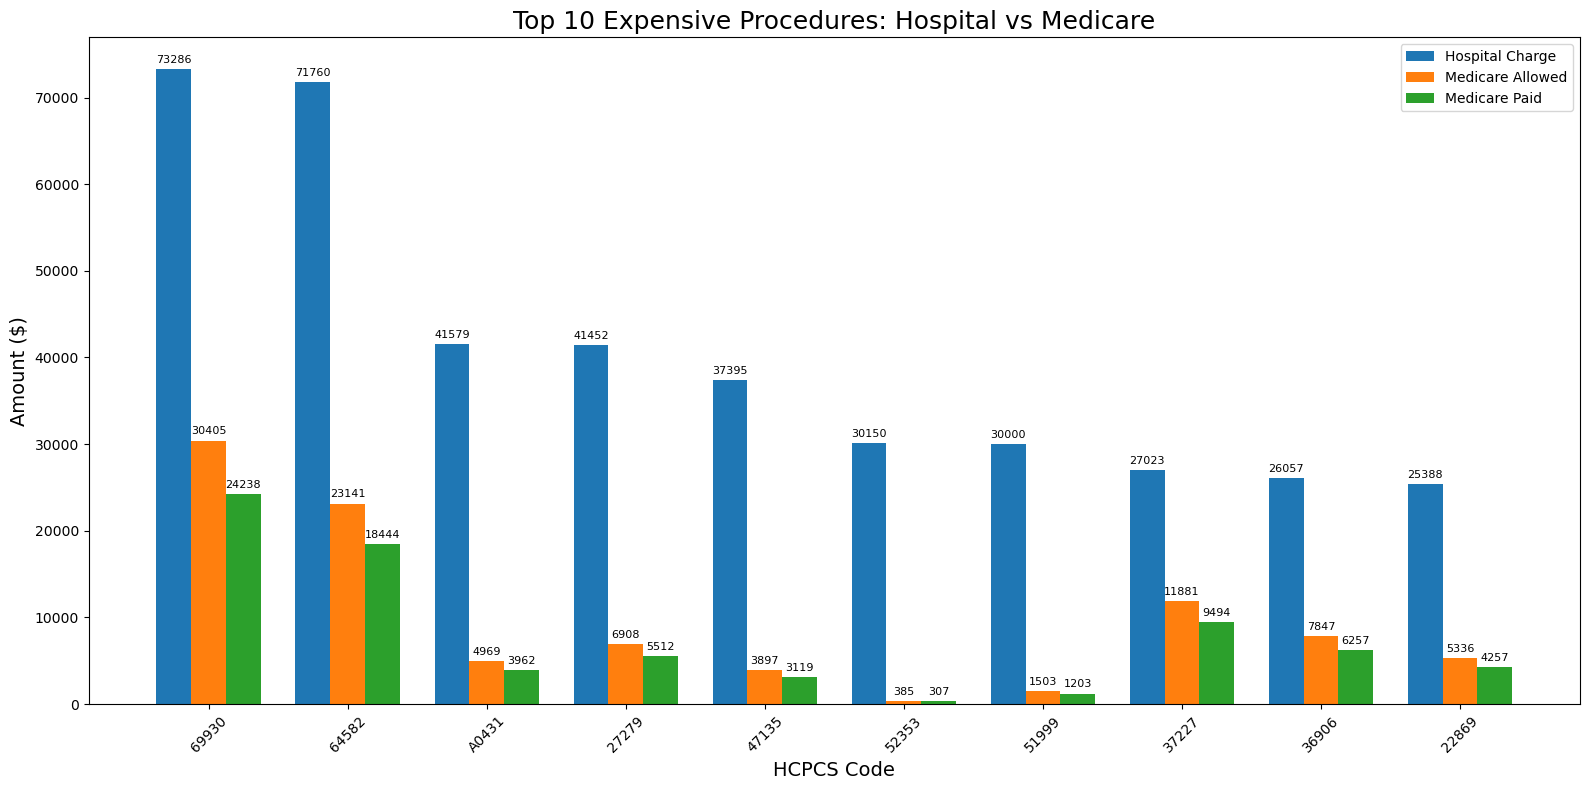

In [68]:
import numpy as np

x = np.arange(len(top_expensive['HCPCS_Cd']))
width = 0.25

fig, ax = plt.subplots(figsize=(16,8))

bar1 = ax.bar(x - width, top_expensive['Avg_Submitted_Charge'], width, label='Hospital Charge')
bar2 = ax.bar(x, top_expensive['Avg_Medicare_Allowed'], width, label='Medicare Allowed')
bar3 = ax.bar(x + width, top_expensive['Avg_Medicare_Payment'], width, label='Medicare Paid')


ax.set_title('Top 10 Expensive Procedures: Hospital vs Medicare', fontsize=18)
ax.set_xlabel('HCPCS Code', fontsize=14)
ax.set_ylabel('Amount ($)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(top_expensive['HCPCS_Cd'], rotation=45)
ax.legend()


def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.0f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

add_labels(bar1)
add_labels(bar2)
add_labels(bar3)

plt.tight_layout()
plt.show()

### Gap and Gap Percentage Between Submitted Charges and Medicare Allowed

In [69]:
cp_group = df.groupby(['HCPCS_Cd','Provider_Type']).agg({'Avg_Submitted_Charge': 'mean', 
                                                          'Avg_Medicare_Allowed':'mean', 'Avg_Medicare_Payment':'mean'}).reset_index()
cp_group = cp_group.round(2)
cp_group

,HCPCS_Cd,Provider_Type,Avg_Submitted_Charge,Avg_Medicare_Allowed,Avg_Medicare_Payment
0,0001A,Mass Immunizer Roster Biller,56.40,35.50,35.50
1,0001A,Pharmacy,43.34,38.81,38.81
2,0002A,Mass Immunizer Roster Biller,82.66,36.64,36.64
3,0002A,Pharmacy,40.00,39.49,39.49
4,0003A,Centralized Flu,100.00,39.65,39.65
...,...,...,...,...,...
9083,U0005,Obstetrics & Gynecology,30.00,24.74,24.74
9084,U0005,Pathology,50.00,24.50,24.50
9085,U0005,Physician Assistant,75.00,24.89,24.89
9086,U0005,Pulmonary Disease,63.06,24.72,24.72


In [70]:
cp_group['gap'] = cp_group['Avg_Submitted_Charge'] - cp_group['Avg_Medicare_Allowed']
cp_group.sort_values('gap', ascending= False).head(15)

,HCPCS_Cd,Provider_Type,Avg_Submitted_Charge,Avg_Medicare_Allowed,Avg_Medicare_Payment,gap
2107,64628,Ambulatory Surgical Center,88374.00,8962.39,7146.44,79411.61
917,22612,Ambulatory Surgical Center,85565.00,8440.40,6740.87,77124.60
1028,27279,Ambulatory Surgical Center,79903.27,12924.82,10312.69,66978.45
1241,33208,Ambulatory Surgical Center,65354.17,7957.44,6350.76,57396.73
2084,64582,Ambulatory Surgical Center,71759.82,23141.20,18444.49,48618.62
2289,69930,Ambulatory Surgical Center,73285.93,30404.92,24238.43,42881.01
1034,27446,Ambulatory Surgical Center,49972.00,8223.41,6571.82,41748.59
1037,27447,Ambulatory Surgical Center,49082.42,8539.15,6817.17,40543.27
957,22869,Ambulatory Surgical Center,50000.00,10258.76,8182.85,39741.24
7970,A0431,Ambulance Service Provider,41578.75,4968.94,3962.35,36609.81


In [71]:
cp_group['gap_percent'] = (((cp_group['Avg_Submitted_Charge'] - cp_group['Avg_Medicare_Allowed']) / cp_group['Avg_Medicare_Allowed']) * 100).round(2)

cp_group.sort_values('gap_percent', ascending= False).head(15)

,HCPCS_Cd,Provider_Type,Avg_Submitted_Charge,Avg_Medicare_Allowed,Avg_Medicare_Payment,gap,gap_percent
5012,91306,Pharmacy,400.00,0.01,0.01,399.99,3999900.00
5015,91309,Internal Medicine,75.00,0.01,0.01,74.99,749900.00
5008,91305,Mass Immunizer Roster Biller,40.00,0.01,0.01,39.99,399900.00
4999,91300,Mass Immunizer Roster Biller,39.23,0.01,0.01,39.22,392200.00
1179,31623,Critical Care (Intensivists),894.10,0.26,0.20,893.84,343784.62
5002,91301,Internal Medicine,30.31,0.01,0.01,30.30,303000.00
5019,91312,Mass Immunizer Roster Biller,27.56,0.01,0.01,27.55,275500.00
5024,91313,Mass Immunizer Roster Biller,27.18,0.01,0.01,27.17,271700.00
5021,91312,Pharmacy,24.82,0.01,0.01,24.81,248100.00
5026,91313,Pharmacy,17.83,0.01,0.01,17.82,178200.00


### Checking the Highest Gap Percentage HCPCS Code

In [72]:
df[df['HCPCS_Cd'] == '91306']

,Provider_NPI,Provider_Last_Name_or_Org,Provider_First_Name,Provider_Credentials,Provider_Address,Provider_City,Provider_State,Provider_Zip,Provider_Type,Medicare_Participation_Indicator,HCPCS_Cd,HCPCS_Desc,Total_Beneficiaries,Total_Services,Total_Beneficiary_Day_Services,Avg_Submitted_Charge,Avg_Medicare_Allowed,Avg_Medicare_Payment,Avg_Medicare_Standardized
7018,1003043712,Gorokhov,Igor,M.D.,9400 Brighton Way,Beverly Hills,CA,90210,Internal Medicine,Y,91306,Sarscov2 vac 50mcg/0.25ml im,16,16.0,16,0.01,0.010000,0.010000,0.01
8344,1003050667,Sprowl,Lisa,M.D.,4400 Duckhorn Drive,Sacramento,CA,95834,Family Practice,Y,91306,Sarscov2 vac 50mcg/0.25ml im,21,21.0,21,0.01,0.010000,0.010000,0.01
14563,1003088840,Connery,Jenny,M.D.,101 Founders Pl,Aspen,CO,81611,Family Practice,Y,91306,Sarscov2 vac 50mcg/0.25ml im,27,28.0,28,0.01,0.010000,0.010000,0.01
16046,1003100645,Swales,Christopher,M.D.,2330 W Covell Blvd,Davis,CA,95616,Family Practice,Y,91306,Sarscov2 vac 50mcg/0.25ml im,35,35.0,35,0.01,0.010000,0.010000,0.01
17231,1003107558,Beckstead,David,M.D.,101 Commerce Park Dr,Westerville,OH,43082,Family Practice,Y,91306,Sarscov2 vac 50mcg/0.25ml im,29,29.0,29,0.01,0.009655,0.009655,0.01
31993,1003245853,Segura,Isela,NA,3406 Bob Rogers Dr,Eagle Pass,TX,78852,Physician Assistant,Y,91306,Sarscov2 vac 50mcg/0.25ml im,44,44.0,44,0.01,0.010000,0.010000,0.01
34643,1003263120,Richeys Drug Store Inc,NA,NA,511 N Main St,Erie,KS,66733,Pharmacy,Y,91306,Sarscov2 vac 50mcg/0.25ml im,65,65.0,65,400.00,0.010000,0.010000,0.01
40166,1003326810,Patel,Moenil,NA,10 Saint Patricks Dr,Waldorf,MD,20603,Nurse Practitioner,Y,91306,Sarscov2 vac 50mcg/0.25ml im,24,24.0,24,0.01,0.010000,0.010000,0.01
51997,1003805755,Wyandot County Office Of Auditor,NA,NA,127 S Sandusky Ave,Upper Sandusky,OH,43351,Public Health or Welfare Agency,Y,91306,Sarscov2 vac 50mcg/0.25ml im,202,202.0,202,0.01,0.010000,0.010000,0.01
61610,1003832346,Lee,David,M.D.,8220 Wymark Dr,Elk Grove,CA,95757,Internal Medicine,Y,91306,Sarscov2 vac 50mcg/0.25ml im,63,65.0,65,0.01,0.010000,0.010000,0.01


In [73]:
cp_group[cp_group['HCPCS_Cd'] == '91306']

,HCPCS_Cd,Provider_Type,Avg_Submitted_Charge,Avg_Medicare_Allowed,Avg_Medicare_Payment,gap,gap_percent
5009,91306,Family Practice,0.01,0.01,0.01,0.00,0.0
5010,91306,Internal Medicine,0.26,0.01,0.01,0.25,2500.0
5011,91306,Nurse Practitioner,0.01,0.01,0.01,0.00,0.0
5012,91306,Pharmacy,400.00,0.01,0.01,399.99,3999900.0
5013,91306,Physician Assistant,0.01,0.01,0.01,0.00,0.0
5014,91306,Public Health or Welfare Agency,0.01,0.01,0.01,0.00,0.0


### Removing The Outliers

In [74]:
df_f = df[df['Avg_Submitted_Charge'] <= df['Avg_Medicare_Allowed'] * 10]
print(df_f.shape)
df_f.head()

(93906, 19)


,Provider_NPI,Provider_Last_Name_or_Org,Provider_First_Name,Provider_Credentials,Provider_Address,Provider_City,Provider_State,Provider_Zip,Provider_Type,Medicare_Participation_Indicator,HCPCS_Cd,HCPCS_Desc,Total_Beneficiaries,Total_Services,Total_Beneficiary_Day_Services,Avg_Submitted_Charge,Avg_Medicare_Allowed,Avg_Medicare_Payment,Avg_Medicare_Standardized
0,1003000126,Enkeshafi,Ardalan,M.D.,6410 Rockledge Dr Ste 304,Bethesda,MD,20817,Internal Medicine,Y,99217,Hospital observation care on day of discharge,42,44.0,44,288.934773,76.932045,58.619773,53.307955
1,1003000126,Enkeshafi,Ardalan,M.D.,6410 Rockledge Dr Ste 304,Bethesda,MD,20817,Internal Medicine,Y,99219,"Initial hospital observation care per day, typ...",17,17.0,17,424.804118,144.920000,109.155294,97.278824
2,1003000126,Enkeshafi,Ardalan,M.D.,6410 Rockledge Dr Ste 304,Bethesda,MD,20817,Internal Medicine,Y,99220,"Initial hospital observation care per day, typ...",35,35.0,35,686.564286,189.998857,151.596857,140.733143
3,1003000126,Enkeshafi,Ardalan,M.D.,6410 Rockledge Dr Ste 304,Bethesda,MD,20817,Internal Medicine,Y,99221,"Initial hospital inpatient care per day, typic...",16,16.0,16,894.991250,100.009375,79.264375,78.499375
4,1003000126,Enkeshafi,Ardalan,M.D.,6410 Rockledge Dr Ste 304,Bethesda,MD,20817,Internal Medicine,Y,99222,"Initial hospital inpatient care per day, typic...",12,12.0,12,511.915000,144.201667,112.946667,103.724167


### Recalculating the Gap and Gap Percentage

In [75]:
cp_f = df_f.groupby(['HCPCS_Cd','Provider_Type']).agg({'Avg_Submitted_Charge': 'mean', 
                                                          'Avg_Medicare_Allowed':'mean', 'Avg_Medicare_Payment':'mean'}).reset_index()
cp_f = cp_f.round(2)
cp_f.head()

,HCPCS_Cd,Provider_Type,Avg_Submitted_Charge,Avg_Medicare_Allowed,Avg_Medicare_Payment
0,0001A,Mass Immunizer Roster Biller,56.40,35.50,35.50
1,0001A,Pharmacy,43.34,38.81,38.81
2,0002A,Mass Immunizer Roster Biller,82.66,36.64,36.64
3,0002A,Pharmacy,40.00,39.49,39.49
4,0003A,Centralized Flu,100.00,39.65,39.65


In [76]:
cp_f['gap'] = cp_f['Avg_Submitted_Charge'] - cp_f['Avg_Medicare_Allowed']
cp_f.sort_values('gap', ascending= False).head(15)

,HCPCS_Cd,Provider_Type,Avg_Submitted_Charge,Avg_Medicare_Allowed,Avg_Medicare_Payment,gap
1945,64628,Ambulatory Surgical Center,88374.00,8962.39,7146.44,79411.61
955,27279,Ambulatory Surgical Center,79903.27,12924.82,10312.69,66978.45
1141,33208,Ambulatory Surgical Center,65354.17,7957.44,6350.76,57396.73
1925,64582,Ambulatory Surgical Center,71759.82,23141.20,18444.49,48618.62
2122,69930,Ambulatory Surgical Center,73285.93,30404.92,24238.43,42881.01
961,27446,Ambulatory Surgical Center,49972.00,8223.41,6571.82,41748.59
890,22869,Ambulatory Surgical Center,50000.00,10258.76,8182.85,39741.24
7708,A0431,Ambulance Service Provider,40853.57,5163.63,4118.45,35689.94
1571,47135,General Surgery,37395.09,3897.10,3118.72,33497.99
964,27447,Ambulatory Surgical Center,39353.09,8632.47,6889.97,30720.62


In [77]:
cp_f['gap_percent'] = (((cp_f['Avg_Submitted_Charge'] - cp_f['Avg_Medicare_Allowed']) / cp_f['Avg_Medicare_Allowed']) * 100).round(2)

cp_f.sort_values('gap_percent', ascending= False).head(15)

,HCPCS_Cd,Provider_Type,Avg_Submitted_Charge,Avg_Medicare_Allowed,Avg_Medicare_Payment,gap,gap_percent
3814,84155,Pain Management,36.00,3.60,3.60,32.40,900.00
1497,43261,Gastroenterology,982.00,98.20,68.10,883.80,900.00
2416,72158,Nurse Practitioner,2150.00,216.12,172.33,1933.88,894.82
830,21825,Nurse Practitioner,355.00,35.74,28.62,319.26,893.28
5852,96360,Rheumatology,400.00,40.37,32.19,359.63,890.83
2685,73660,Independent Diagnostic Testing Facility (IDTF),233.00,23.52,15.53,209.48,890.65
1945,64628,Ambulatory Surgical Center,88374.00,8962.39,7146.44,79411.61,886.05
2193,70553,Neurosurgery,2150.00,218.41,160.18,1931.59,884.39
157,00865,Anesthesiology,2527.87,256.82,204.49,2271.05,884.30
5735,95925,Neurology,287.40,29.24,23.38,258.16,882.90


In [78]:
cp_f.sort_values('gap_percent', ascending= True).head(15)

,HCPCS_Cd,Provider_Type,Avg_Submitted_Charge,Avg_Medicare_Allowed,Avg_Medicare_Payment,gap,gap_percent
7466,99442,Allergy/ Immunology,60.00,60.31,27.74,-0.31,-0.51
6135,97763,Physical Therapist in Private Practice,30.02,30.15,23.09,-0.13,-0.43
1290,36473,Interventional Cardiology,1454.30,1459.76,1153.83,-5.46,-0.37
276,0275T,Diagnostic Radiology,600.00,601.33,481.33,-1.33,-0.22
2845,75820,Clinical Cardiac Electrophysiology,38.68,38.75,31.01,-0.07,-0.18
7227,99309,Infectious Disease,80.00,80.05,64.05,-0.05,-0.06
5796,96130,Physical Medicine and Rehabilitation,138.88,138.88,87.52,0.00,0.00
4780,91305,Internal Medicine,0.01,0.01,0.01,0.00,0.00
4781,91306,Family Practice,0.01,0.01,0.01,0.00,0.00
4782,91306,Internal Medicine,0.01,0.01,0.01,0.00,0.00


### Checking Which Provider Type Charges The Most for the Highest Gap Percentage HCPCS Code

In [79]:
cp_84 = cp_f[cp_f['HCPCS_Cd'] == '84155']

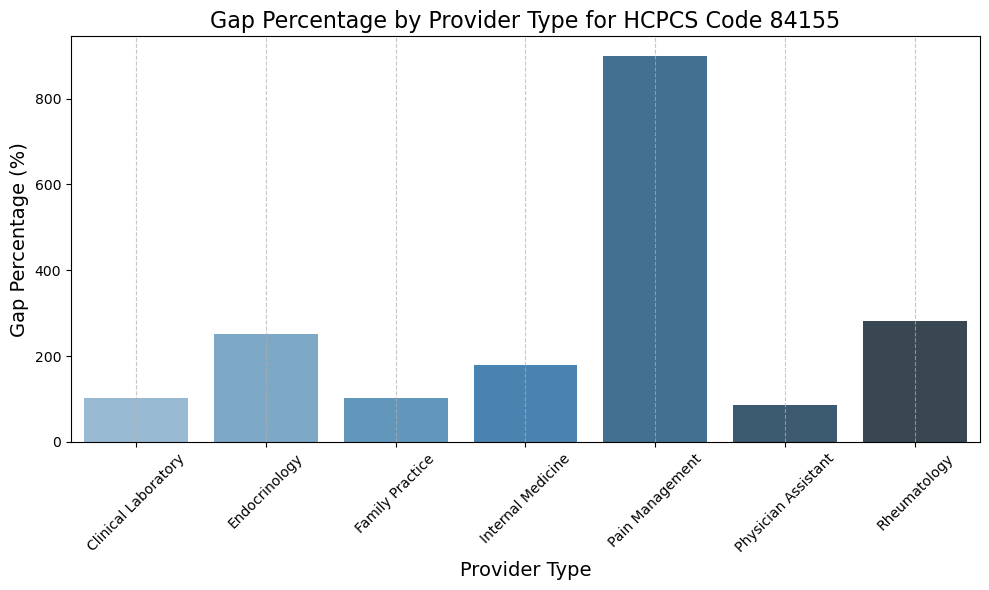

In [80]:
import warnings
warnings.filterwarnings('ignore')



plt.figure(figsize=(10,6))
sns.barplot(
    data=cp_84,
    x='Provider_Type',
    y='gap_percent',
    palette='Blues_d'
)
plt.title('Gap Percentage by Provider Type for HCPCS Code 84155', fontsize=16)
plt.ylabel('Gap Percentage (%)', fontsize=14)
plt.xlabel('Provider Type', fontsize=14)
plt.xticks(rotation = 45)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Checking Rest of the Data for Provider Type Who Charges the Most, for Other HCPCS Code

In [81]:
df_pm = df_f[df_f['Provider_Type'] == 'Pain Management']

In [82]:
df_pm_c = df_pm.groupby('HCPCS_Cd').agg({
    'Avg_Submitted_Charge': 'mean',
    'Avg_Medicare_Allowed': 'mean',
    'Avg_Medicare_Payment': 'mean'
}).reset_index()
df_pm_c = df_pm_c.round(2)
df_pm_c

,HCPCS_Cd,Avg_Submitted_Charge,Avg_Medicare_Allowed,Avg_Medicare_Payment
0,00142,470.45,96.51,77.17
1,00400,542.14,96.04,76.65
2,00532,637.03,99.58,79.52
3,00600,769.64,168.37,130.43
4,00630,1120.59,140.03,110.10
...,...,...,...,...
156,Q4252,954.49,944.43,754.59
157,Q4253,939.87,918.58,732.17
158,Q9966,2.00,0.33,0.26
159,Q9967,1.00,0.11,0.09


In [83]:
# Recalculate the gap
df_pm_c['gap'] = (df_pm_c['Avg_Submitted_Charge'] - df_pm_c['Avg_Medicare_Allowed'])
df_pm_c['gap_percent'] = ((df_pm_c['gap'] / df_pm_c['Avg_Medicare_Allowed']) * 100).round(2)
df_pm_c.sort_values('gap_percent', ascending= False)

,HCPCS_Cd,Avg_Submitted_Charge,Avg_Medicare_Allowed,Avg_Medicare_Payment,gap,gap_percent
92,84155,36.00,3.60,3.60,32.40,900.00
71,72146,998.64,104.86,68.99,893.78,852.36
159,Q9967,1.00,0.11,0.09,0.89,809.09
70,72114,265.17,30.32,23.34,234.85,774.57
12,01922,897.33,103.00,82.25,794.33,771.19
...,...,...,...,...,...,...
160,U0002,75.00,51.20,51.20,23.80,46.48
154,Q4188,950.00,917.80,731.26,32.20,3.51
157,Q4253,939.87,918.58,732.17,21.29,2.32
156,Q4252,954.49,944.43,754.59,10.06,1.07


In [84]:
df_pm_c[df_pm_c['gap_percent'] > 300.00].shape[0]

57

### Top Expensive Provider

In [85]:
top_provider = df_f.groupby(['Provider_Type']).agg({'Avg_Submitted_Charge': 'mean', 
                                                    'Avg_Medicare_Allowed':'mean'}).sort_values(by='Avg_Submitted_Charge'
                                                                                                , ascending=False).head(10).reset_index()


top_provider

,Provider_Type,Avg_Submitted_Charge,Avg_Medicare_Allowed
0,Ambulatory Surgical Center,6511.979288,1635.099696
1,Thoracic Surgery,2096.271104,590.451543
2,Cardiac Surgery,1695.189270,436.628268
3,Ambulance Service Provider,1453.511313,389.706464
4,Neurosurgery,1243.456859,332.553246
5,Certified Registered Nurse Anesthetist (CRNA),860.082492,141.960898
6,Medical Toxicology,834.411359,89.190636
7,Anesthesiology,788.826893,131.946253
8,Anesthesiology Assistant,731.654318,112.554875
9,Micrographic Dermatologic Surgery,727.290979,242.650939


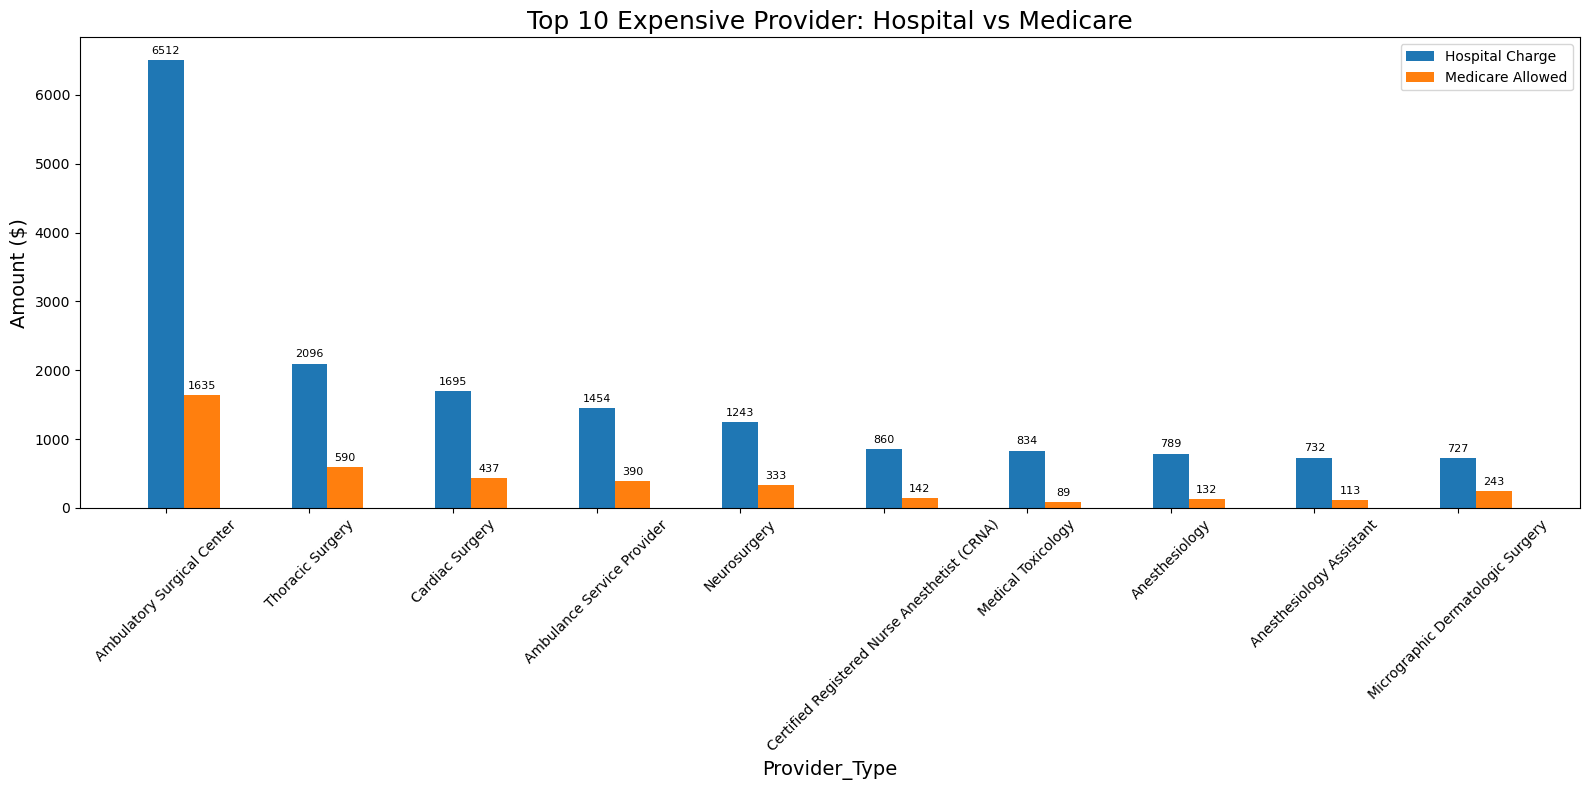

In [86]:
x = np.arange(len(top_provider['Provider_Type']))
width = 0.25

fig, ax = plt.subplots(figsize=(16,8))

bar1 = ax.bar(x , top_provider['Avg_Submitted_Charge'], width, label='Hospital Charge')
bar2 = ax.bar(x + width, top_provider['Avg_Medicare_Allowed'], width, label='Medicare Allowed')


ax.set_title('Top 10 Expensive Provider: Hospital vs Medicare', fontsize=18)
ax.set_xlabel('Provider_Type', fontsize=14)
ax.set_ylabel('Amount ($)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(top_provider['Provider_Type'], rotation = 45)
ax.legend()


def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.0f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

add_labels(bar1)
add_labels(bar2)

plt.tight_layout()
plt.show()

### Creating K-Means Clusters for Provider Types

In [87]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Group by provider name or type
provider_data = df_f.groupby('Provider_Type')[['Avg_Submitted_Charge', 'Avg_Medicare_Allowed']].mean().reset_index()

# Normalize
scaler = StandardScaler()
scaled_data = scaler.fit_transform(provider_data[['Avg_Submitted_Charge', 'Avg_Medicare_Allowed']])

# KMeans
kmeans = KMeans(n_clusters=3, random_state=0)
provider_data['Cluster'] = kmeans.fit_predict(scaled_data)

In [88]:
# Visualizing the Scatter Plot for Clusters
fig = px.scatter(
    provider_data,
    x='Avg_Submitted_Charge',
    y='Avg_Medicare_Allowed',
    color='Cluster', 
    hover_name='Provider_Type',
    hover_data={
        'Avg_Submitted_Charge': ':.2f',
        'Avg_Medicare_Allowed': ':.2f',
        'Cluster': True
    },
    title='Clustering of Provider Behavior: Charges vs Medicare Payment',
    labels={
        'Avg_Submitted_Charge': 'Avg Submitted Charge ($)',
        'Avg_Medicare_Allowed': 'Avg Medicare Allowed ($)',
        'Cluster': 'Cluster Group'
    },
    template='plotly_white',
    width=950,
    height=600
)

fig.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(title_font_size=20, legend_title_text='Cluster', legend_title_font_size=14)

fig.show()